In [3]:
from prepare_time_boroughs import prepare_yearly_boroughs, prepare_quarterly_boroughs, prepare_monthly_boroughs
from forecasting_tools import sarima_forecast, bayesian_ridge_forecast, plot_borough_forecasts, prophet_forecast, plot_cluster_forecasts
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

In [4]:
df_year = prepare_yearly_boroughs()
df_quarter = prepare_quarterly_boroughs()
df_month = prepare_monthly_boroughs()

quarter_positions = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44]
month_positions=[2, 14, 26, 38, 50, 62, 74, 86, 98, 110, 122, 134]
year_labels=['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028']

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


In [5]:
df_year_covid = prepare_yearly_boroughs(ADJUST_COVID=True)
df_quarter_covid = prepare_quarterly_boroughs(ADJUST_COVID=True)
df_month_covid = prepare_monthly_boroughs(ADJUST_COVID=True)

PREPARING YEARLY DATA...
COMPLETE
PREPARING QUARTERLY DATA...
COMPLETE
PREPARING MONTHLY DATA...
COMPLETE


In [6]:
df_prophet_forecast = prophet_forecast(df_month, 72, 36)
df_prophet_quarter = prophet_forecast(df_quarter, 22, 20)

df_covid_month = prophet_forecast(df_month_covid, 72, 36)
df_covid_quarter = prophet_forecast(df_quarter_covid, 22, 20)

print("quarter prophet", np.mean(df_prophet_quarter[['mape']]))
print("monthly prophet", np.mean(df_prophet_forecast[['mape']]))

print("covid quarter prophet", np.mean(df_covid_quarter[['mape']]))
print("covid monthly prophet", np.mean(df_covid_month[['mape']]))

12:09:34 - cmdstanpy - INFO - Chain [1] start processing
12:09:34 - cmdstanpy - INFO - Chain [1] done processing
12:09:34 - cmdstanpy - INFO - Chain [1] start processing
12:09:34 - cmdstanpy - INFO - Chain [1] done processing
12:09:34 - cmdstanpy - INFO - Chain [1] start processing
12:09:34 - cmdstanpy - INFO - Chain [1] done processing
12:09:34 - cmdstanpy - INFO - Chain [1] start processing
12:09:34 - cmdstanpy - INFO - Chain [1] done processing
12:09:34 - cmdstanpy - INFO - Chain [1] start processing
12:09:35 - cmdstanpy - INFO - Chain [1] done processing
12:09:35 - cmdstanpy - INFO - Chain [1] start processing
12:09:35 - cmdstanpy - INFO - Chain [1] done processing
12:09:35 - cmdstanpy - INFO - Chain [1] start processing
12:09:35 - cmdstanpy - INFO - Chain [1] done processing
12:09:35 - cmdstanpy - INFO - Chain [1] start processing
12:09:35 - cmdstanpy - INFO - Chain [1] done processing
12:09:35 - cmdstanpy - INFO - Chain [1] start processing
12:09:35 - cmdstanpy - INFO - Chain [1]

quarter prophet 16.956046281912965
monthly prophet 27.263849646305985
covid quarter prophet 16.941504215661315
covid monthly prophet 28.137942479311253


In [5]:
results = {}
for cps in [0.01, 0.05, 0.1, 0.5]:
    for mode in ['additive', 'multiplicative']:
        df_result = prophet_forecast(df_quarter, 22, 7, tuned=True, changepoint_prior_scale=cps, seasonality_mode=mode)
        mean_mape = np.mean(df_result['mape'])
        results[(cps, mode)] = mean_mape
        print(f"cps={cps}, mode={mode}: {mean_mape:.2f}%")

14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1] done processing
14:20:25 - cmdstanpy - INFO - Chain [1] start processing
14:20:25 - cmdstanpy - INFO - Chain [1]

cps=0.01, mode=additive: 16.42%


14:20:27 - cmdstanpy - INFO - Chain [1] done processing
14:20:27 - cmdstanpy - INFO - Chain [1] start processing
14:20:27 - cmdstanpy - INFO - Chain [1] done processing
14:20:27 - cmdstanpy - INFO - Chain [1] start processing
14:20:27 - cmdstanpy - INFO - Chain [1] done processing
14:20:27 - cmdstanpy - INFO - Chain [1] start processing
14:20:27 - cmdstanpy - INFO - Chain [1] done processing
14:20:27 - cmdstanpy - INFO - Chain [1] start processing
14:20:28 - cmdstanpy - INFO - Chain [1] done processing
14:20:28 - cmdstanpy - INFO - Chain [1] start processing
14:20:28 - cmdstanpy - INFO - Chain [1] done processing
14:20:28 - cmdstanpy - INFO - Chain [1] start processing
14:20:28 - cmdstanpy - INFO - Chain [1] done processing
14:20:28 - cmdstanpy - INFO - Chain [1] start processing
14:20:28 - cmdstanpy - INFO - Chain [1] done processing
14:20:28 - cmdstanpy - INFO - Chain [1] start processing
14:20:28 - cmdstanpy - INFO - Chain [1] done processing
14:20:28 - cmdstanpy - INFO - Chain [1] 

cps=0.01, mode=multiplicative: 16.59%


14:20:30 - cmdstanpy - INFO - Chain [1] start processing
14:20:30 - cmdstanpy - INFO - Chain [1] done processing
14:20:30 - cmdstanpy - INFO - Chain [1] start processing
14:20:30 - cmdstanpy - INFO - Chain [1] done processing
14:20:30 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1] done processing
14:20:31 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1] done processing
14:20:31 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1] done processing
14:20:31 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1] done processing
14:20:31 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1] done processing
14:20:31 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1] done processing
14:20:31 - cmdstanpy - INFO - Chain [1] start processing
14:20:31 - cmdstanpy - INFO - Chain [1]

...

cps=0.1, mode=multiplicative: 18.15%


14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:49 - cmdstanpy - INFO - Chain [1] done processing
14:20:49 - cmdstanpy - INFO - Chain [1] start processing
14:20:50 - cmdstanpy - INFO - Chain [1] done processing
14:20:50 - cmdstanpy - INFO - Chain [1] start processing
14:20:50 - cmdstanpy - INFO - Chain [1] done processing
14:20:50 - cmdstanpy - INFO - Chain [1] 

cps=0.5, mode=additive: 22.86%


14:20:57 - cmdstanpy - INFO - Chain [1] done processing
14:20:57 - cmdstanpy - INFO - Chain [1] start processing
14:21:03 - cmdstanpy - INFO - Chain [1] done processing
14:21:03 - cmdstanpy - INFO - Chain [1] start processing
14:21:08 - cmdstanpy - INFO - Chain [1] done processing
14:21:08 - cmdstanpy - INFO - Chain [1] start processing
14:21:13 - cmdstanpy - INFO - Chain [1] done processing
14:21:13 - cmdstanpy - INFO - Chain [1] start processing
14:21:18 - cmdstanpy - INFO - Chain [1] done processing
14:21:18 - cmdstanpy - INFO - Chain [1] start processing
14:21:24 - cmdstanpy - INFO - Chain [1] done processing
14:21:24 - cmdstanpy - INFO - Chain [1] start processing
14:21:29 - cmdstanpy - INFO - Chain [1] done processing
14:21:29 - cmdstanpy - INFO - Chain [1] start processing
14:21:34 - cmdstanpy - INFO - Chain [1] done processing
14:21:34 - cmdstanpy - INFO - Chain [1] start processing
14:21:39 - cmdstanpy - INFO - Chain [1] done processing
14:21:39 - cmdstanpy - INFO - Chain [1] 

cps=0.5, mode=multiplicative: 28.62%


In [7]:
results

{(0.01, 'additive'): np.float64(16.41859296205476),
 (0.01, 'multiplicative'): np.float64(16.591238508527297),
 (0.05, 'additive'): np.float64(16.41987808278576),
 (0.05, 'multiplicative'): np.float64(16.77673780670939),
 (0.1, 'additive'): np.float64(16.582293314693175),
 (0.1, 'multiplicative'): np.float64(18.145158313158532),
 (0.5, 'additive'): np.float64(22.861985179152107),
 (0.5, 'multiplicative'): np.float64(28.617018292910135)}

------------------------------------
----- QUARTER PROPHET FORECAST -----
------------------------------------


KeyError: 'borough'

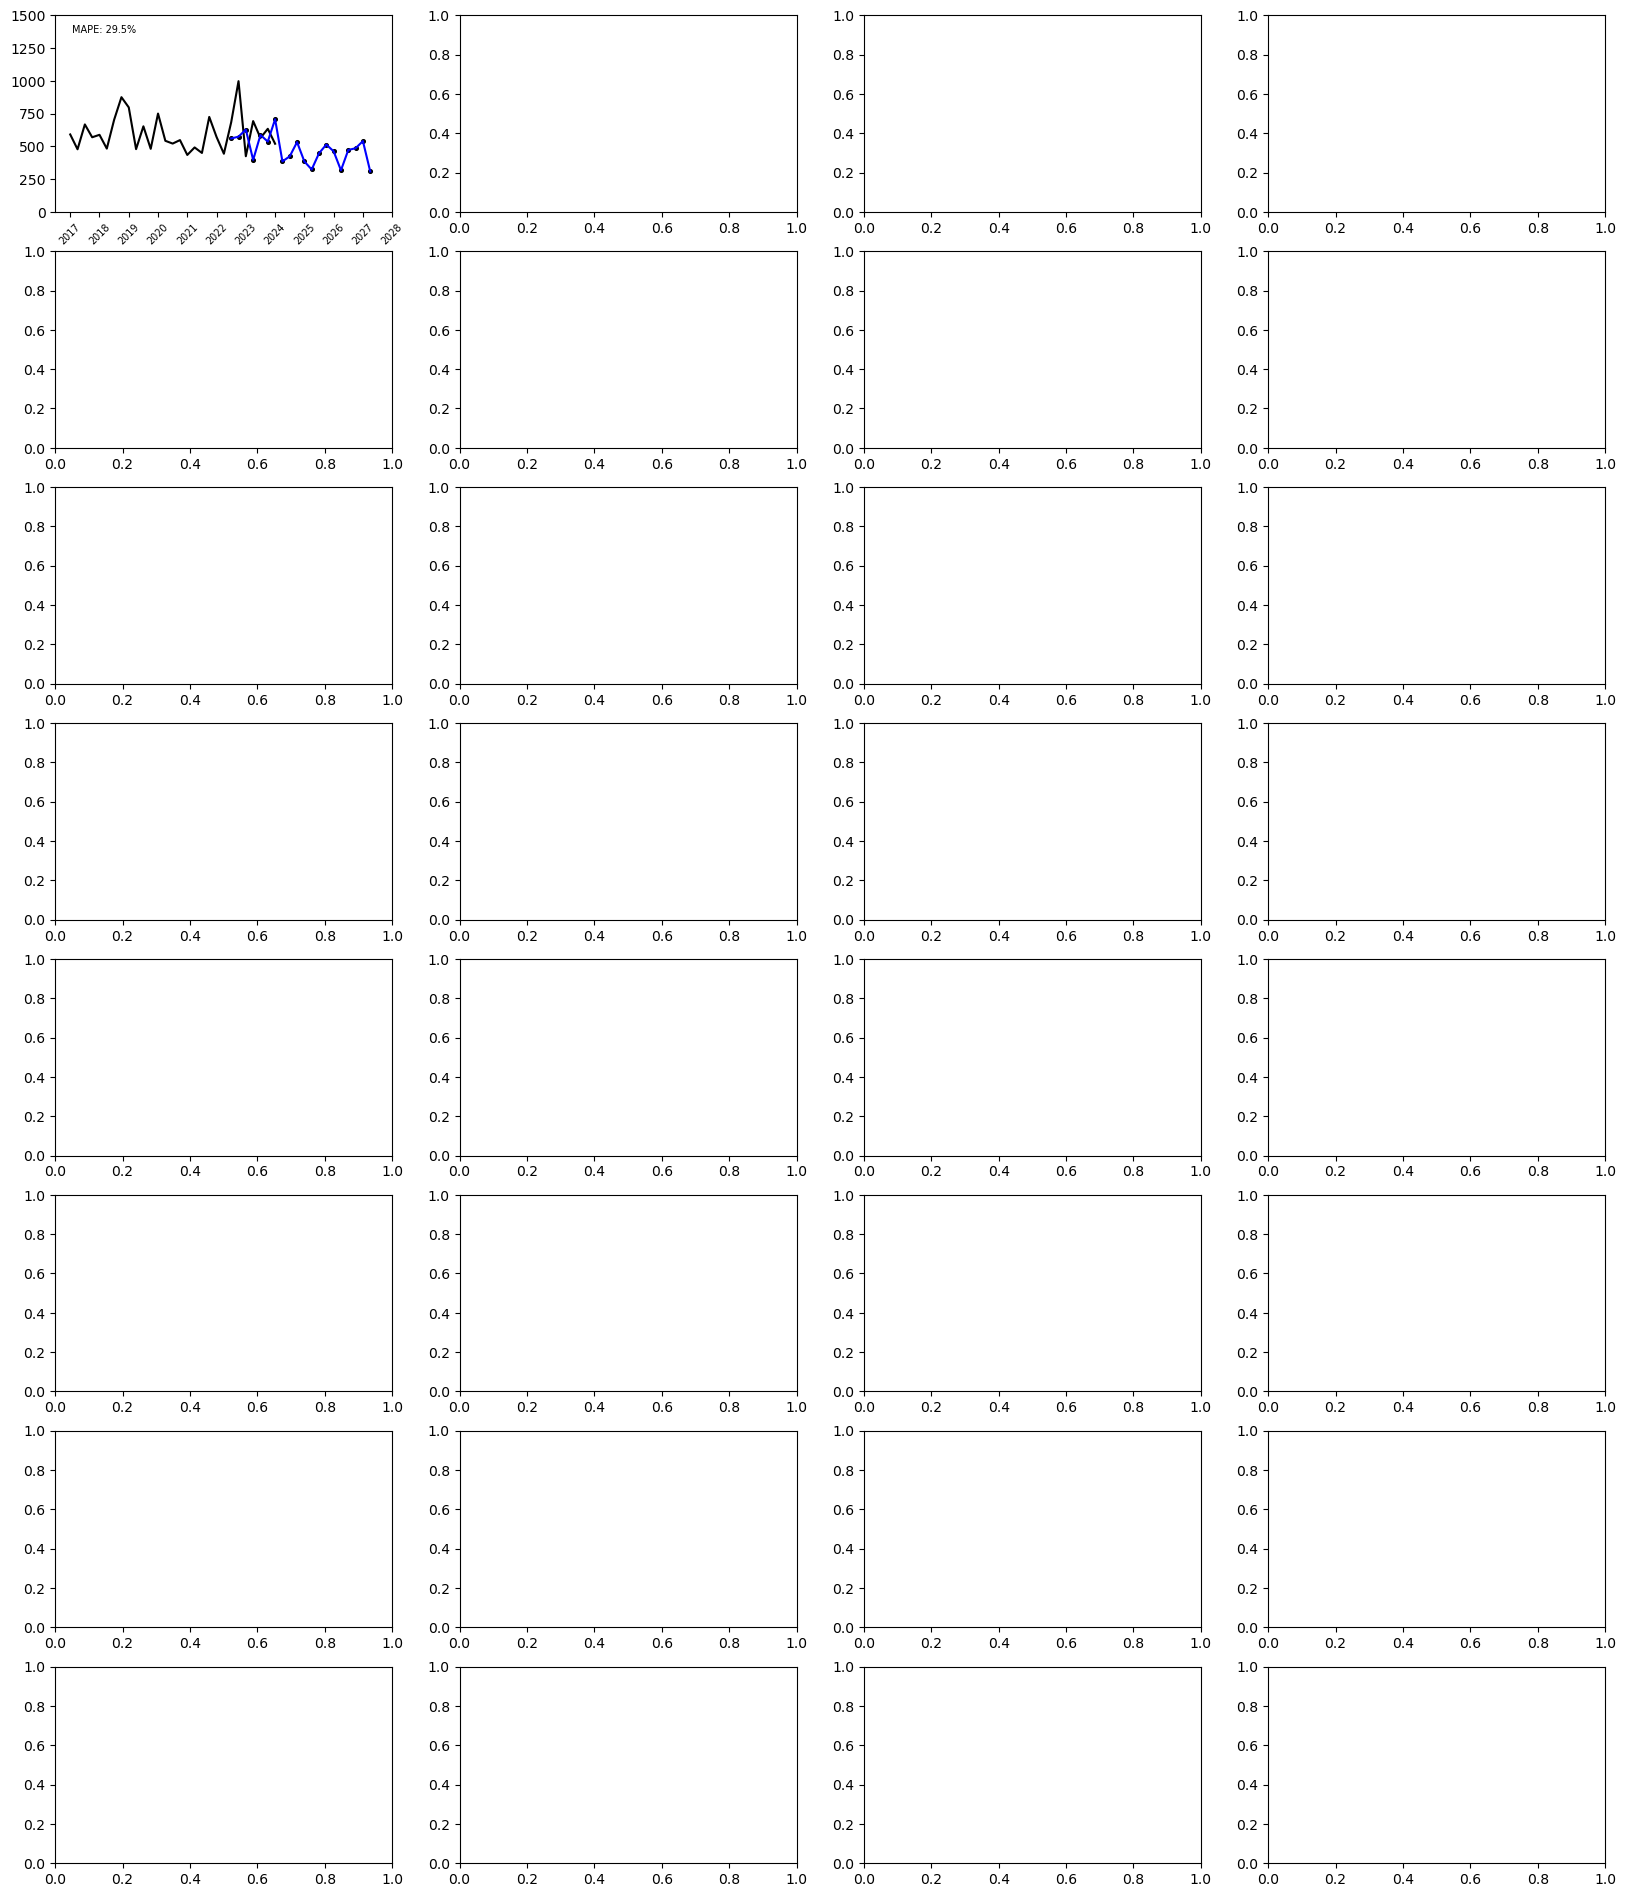

In [ ]:
print("------------------------------------")
print("----- QUARTER PROPHET FORECAST -----")
print("------------------------------------")
plot_borough_forecasts(df_prophet_quarter, 22, xtick_positions=quarter_positions, xtick_labels=year_labels)

------------------------------------
----- MONTHLY PROPHET FORECAST -----
------------------------------------


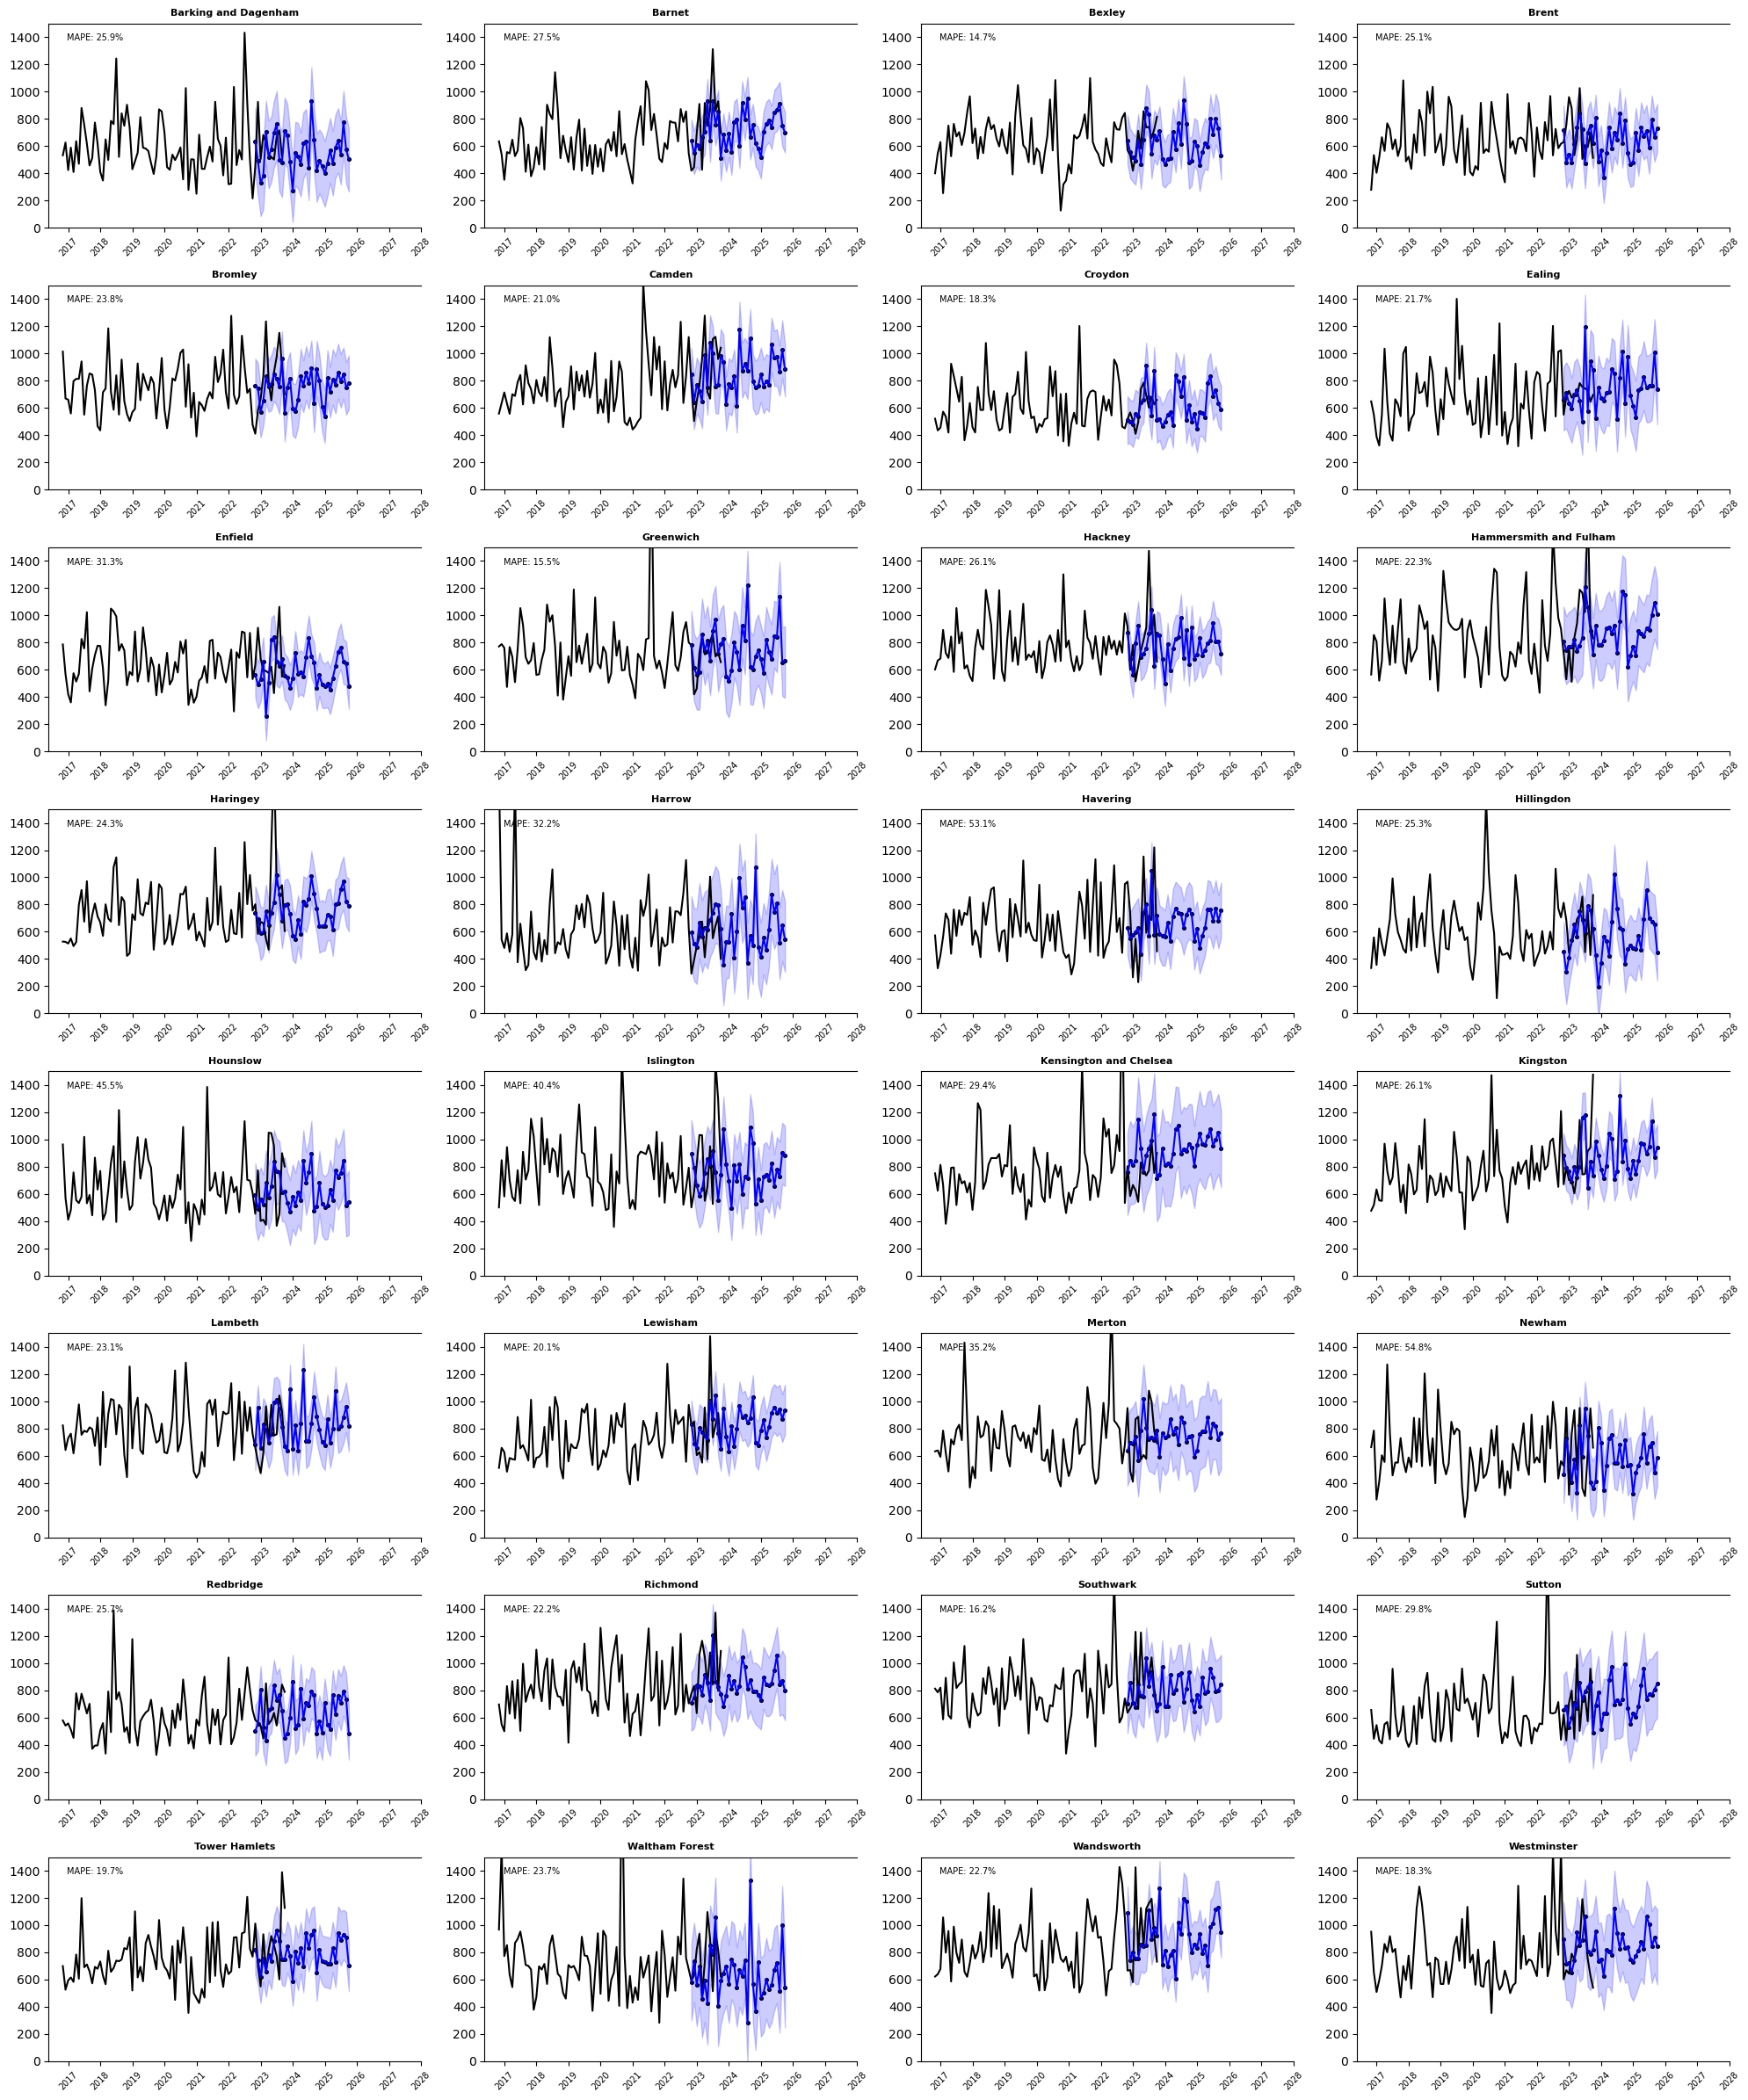

In [10]:
print("------------------------------------")
print("----- MONTHLY PROPHET FORECAST -----")
print("------------------------------------")
plot_prophet_forecasts(df_prophet_forecast, 72, xtick_positions=month_positions, xtick_labels=year_labels)